# 03 - Calibration

*This notebook is a thin view: it renders artifacts persisted by the pipeline (`make data features train evaluate figures`). No result is computed here.*

In [1]:
import json, sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd
from IPython.display import Image, display

RESULTS = Path.cwd().parent / "results" / "metrics"
FIGURES = Path.cwd().parent / "reports" / "figures"

def load(name):
    with open(RESULTS / f"{name}.json") as fh:
        return json.load(fh)

def fig(name):
    display(Image(str(FIGURES / f"{name}.png"), width=880))


In [2]:
cal = load('stage3_calibration')
pd.DataFrame(cal['val_metrics']).round(5)

,uncalibrated,platt,isotonic
brier,0.01866,0.01820,0.01802
log_loss,0.08735,0.07596,0.07450
ece,0.01206,0.00259,0.00000


In [3]:
calt = load('stage3_calibration_test')
pd.DataFrame(calt['test_metrics']).round(5)

,uncalibrated,platt,isotonic
brier,0.02170,0.02116,0.02118
log_loss,0.10534,0.08888,0.08844
ece,0.01456,0.00302,0.00408


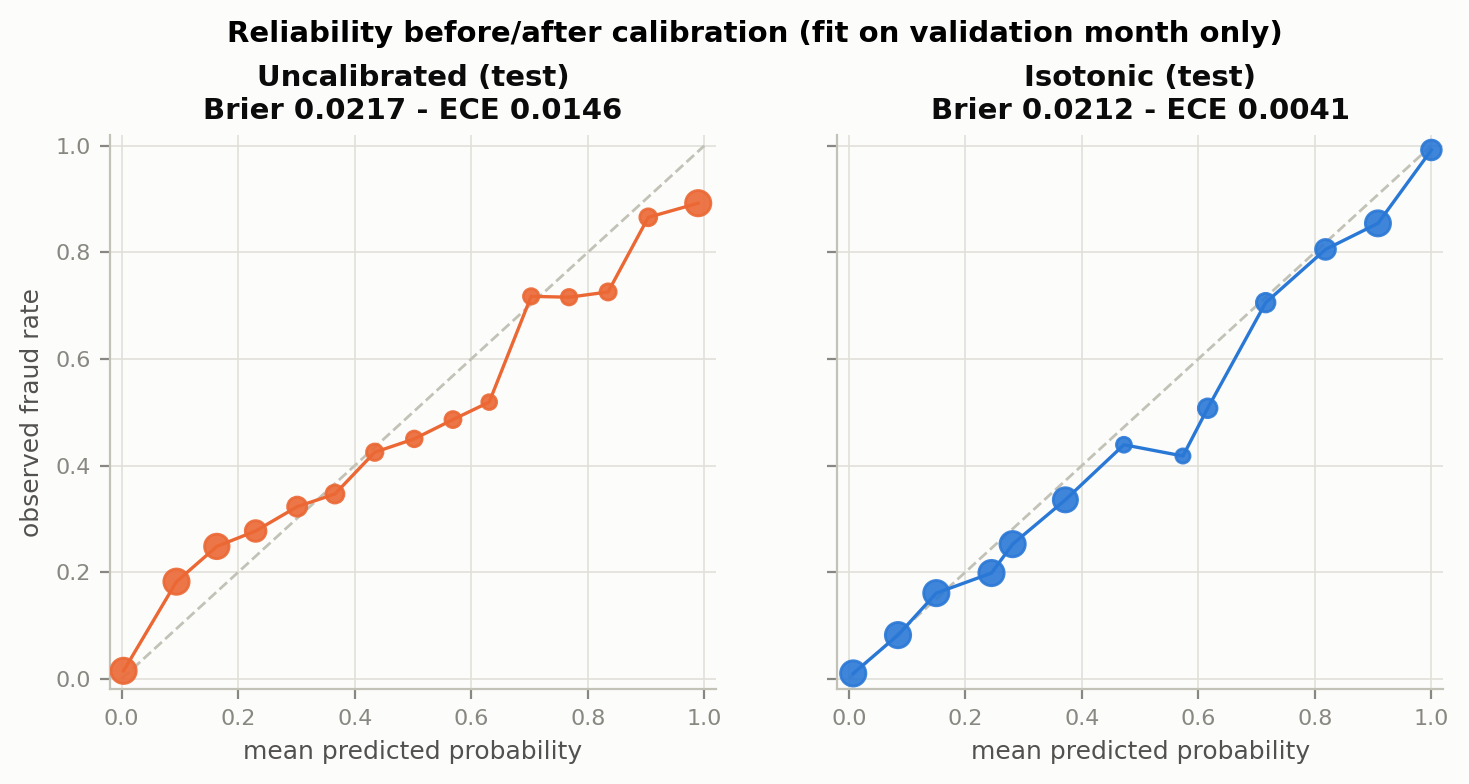

In [4]:
fig('figure_04_reliability')

Class-weighted training deliberately distorts probabilities (scale_pos_weight); calibration on the validation month repairs them. The chosen method is selected by validation Brier score and frozen before the test month is touched.

In [5]:
cal['chosen_method'], cal['platt_coef']

('isotonic', [0.6703814287706863, -0.07055997099265919])